# Install package

In [0]:
%pip install openpyxl

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


# import Libraries 

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [0]:

df = spark.read.table("workspace.default.1785258801617_sales_case_study_2021_1").toPandas()

In [0]:
df=spark.table("workspace.default.`1785258801617_sales_case_study_2021_1`")
display(df.limit(10))

Date,Sales,Cost Of Sales,Quantity Sold
2013-12-30T00:00:00.000Z,223937.967869726530,230079.621012448040,6827
2013-12-31T00:00:00.000Z,300345.484563985660,306986.120484283190,9268
2014-01-01T00:00:00.000Z,86782.467727417796,87986.318214449886,2678
2014-01-02T00:00:00.000Z,200173.116752677160,202881.177706232610,6175
2014-01-03T00:00:00.000Z,326906.074176330640,333806.291873354810,10084
2014-01-04T00:00:00.000Z,307043.935422161890,313652.348272363540,9470
2014-01-05T00:00:00.000Z,179188.884487809730,183083.284984026980,5524
2014-01-06T00:00:00.000Z,306351.950858991880,313446.068148843010,9448
2014-01-07T00:00:00.000Z,224020.409968478340,229533.973728379670,6911
2014-01-08T00:00:00.000Z,101836.402236237100,99381.967517224926,2990


# Data inspection

In [0]:
# Preview data
print(df.head())

Row(Date=datetime.datetime(2013, 12, 30, 0, 0), Sales=Decimal('223937.967869726530'), Cost Of Sales=Decimal('230079.621012448040'), Quantity Sold=6827)


# showing all the columns labels in dataframe

In [0]:
df.columns

['Date', 'Sales', 'Cost Of Sales', 'Quantity Sold']

# check columns data types 

In [0]:
df.dtypes

[('Date', 'timestamp'),
 ('Sales', 'decimal(18,12)'),
 ('Cost Of Sales', 'decimal(18,12)'),
 ('Quantity Sold', 'bigint')]

In [0]:
#counting the number of rows and columns in dataset
(df.count(), len(df.columns))

(1053, 4)

In [0]:
df.describe()

DataFrame[summary: string, Sales: string, Cost Of Sales: string, Quantity Sold: string]

In [0]:
from pyspark.sql.functions import col, sum as spark_sum, when

# Count null values per column
df.select([spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns]).show()

+----+-----+-------------+-------------+
|Date|Sales|Cost Of Sales|Quantity Sold|
+----+-----+-------------+-------------+
|   0|    0|            0|            0|
+----+-----+-------------+-------------+



In [0]:
# checking the number of nan missing values per column,and checking the data type.
from pyspark.sql.functions import col, count, when

# Show schema (data types)
df.printSchema()

# Count null values per column
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

root
 |-- Date: timestamp (nullable = true)
 |-- Sales: decimal(18,12) (nullable = true)
 |-- Cost Of Sales: decimal(18,12) (nullable = true)
 |-- Quantity Sold: long (nullable = true)

+----+-----+-------------+-------------+
|Date|Sales|Cost Of Sales|Quantity Sold|
+----+-----+-------------+-------------+
|   0|    0|            0|            0|
+----+-----+-------------+-------------+



In [0]:
#checking for the duplicated values in our table dataset
total_rows = df.count()
distinct_rows = df.distinct().count()
duplicates = total_rows - distinct_rows
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [0]:
#calculating  daily sales  price  per unite

In [0]:
# Daily price per unit
from pyspark.sql.functions import col

# Calculate unit price
df = df.withColumn("Unit_Price", col("Sales") / col("Quantity Sold"))

# Show first few results
df.select("Date", "Unit_Price").show(10)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------------------+--------------------+
|               Date|          Unit_Price|
+-------------------+--------------------+
|2013-12-30 00:00:00|32.80181161120939...|
|2013-12-31 00:00:00|32.40672038886336...|
|2014-01-01 00:00:00|32.40570116781844...|
|2014-01-02 00:00:00|32.41669906925945...|
|2014-01-03 00:00:00|32.41829375013195...|
|2014-01-04 00:00:00|32.42280205091466...|
|2014-01-05 00:00:00|32.43824845905317...|
|2014-01-06 00:00:00|32.42505830429634...|
|2014-01-07 00:00:00|32.41504991585564...|
|2014-01-08 00:00:00|34.05899740342377...|
+-------------------+--------------------+
only showing top 10 rows


In [0]:
# Calculate Price per Unit using Spark operations
from pyspark.sql.functions import col

df = df.withColumn("Price_per_Unit", col("Sales") / col("Quantity Sold"))

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


#  checking the overall average unit sales price of the product

In [0]:
# calculating Average unit sales price
from pyspark.sql.functions import mean, col
df_with_price = df.withColumn("Price_per_Unit", col("Sales") / col("Quantity Sold"))
avg_unit_price = df_with_price.select(mean("Price_per_Unit")).collect()[0][0]
print("Average Unit Sales Price:", round(avg_unit_price, 2))

Average Unit Sales Price: 37.07


# checking the daily profitability

In [0]:
# Calculate Daily % gross profit
from pyspark.sql.functions import col
df = df.withColumn("Gross_Profit_%", ((col("Sales") - col("Cost Of Sales")) / col("Sales")) * 100)

In [0]:
# Gross profit percentage per day
# Display the Gross_Profit_% column that was already calculated in Cell 24
from pyspark.sql.functions import col, round as spark_round
df = df.withColumn("Gross_Profit_%_Rounded", spark_round(col("Gross_Profit_%"), 2))

# Show results
df.select("Date", "Gross_Profit_%_Rounded").show(5)

+-------------------+----------------------+
|               Date|Gross_Profit_%_Rounded|
+-------------------+----------------------+
|2013-12-30 00:00:00|                 -2.74|
|2013-12-31 00:00:00|                 -2.21|
|2014-01-01 00:00:00|                 -1.39|
|2014-01-02 00:00:00|                 -1.35|
|2014-01-03 00:00:00|                 -2.11|
+-------------------+----------------------+
only showing top 5 rows


# checking for promotional periods which  days when sales spiked unusually high

In [0]:
#Identify promotional periods top 3 sales spikes.
from pyspark.sql.functions import col, desc
promo_periods = df.orderBy(desc("Sales")).limit(3)
print("Promotional Periods:")
promo_periods.select("Date", "Sales").show()

Promotional Periods:
+-------------------+-------------------+
|               Date|              Sales|
+-------------------+-------------------+
|2014-03-01 00:00:00|846678.388160804050|
|2014-08-30 00:00:00|717096.712818359370|
|2015-04-02 00:00:00|715032.189870242960|
+-------------------+-------------------+



In [0]:
# Sort by lowest unit price
from pyspark.sql.functions import col
promo_periods = df.orderBy(col("Price_per_Unit")).limit(3)
promo_periods.select("Date", "Price_per_Unit", "Quantity Sold").show()


+-------------------+--------------------+-------------+
|               Date|      Price_per_Unit|Quantity Sold|
+-------------------+--------------------+-------------+
|2014-09-02 00:00:00|30.70237008862256...|        15291|
|2014-09-08 00:00:00|30.72147495970165...|         7958|
|2014-09-01 00:00:00|30.72155504009288...|        19366|
+-------------------+--------------------+-------------+



In [0]:
# checking the relationship between changes in price and changes in sales volume,like to measure how promotions or price adjustments affect demand

In [0]:
#Price Elasticity of Demand (simplified)
from pyspark.sql.functions import col, lag
from pyspark.sql.window import Window

# First, add Price_per_Unit column if it doesn't exist
if "Price_per_Unit" not in df.columns:
    df = df.withColumn("Price_per_Unit", col("Sales") / col("Quantity Sold"))

# Define window ordered by Date
window_spec = Window.orderBy("Date")

# Calculate % change in Quantity Sold
df = df.withColumn(
    "Delta_Q",
    ((col("Quantity Sold") - lag("Quantity Sold", 1).over(window_spec)) / lag("Quantity Sold", 1).over(window_spec)) * 100
)

# Calculate % change in Price per Unit
df = df.withColumn(
    "Delta_P",
    ((col("Price_per_Unit") - lag("Price_per_Unit", 1).over(window_spec)) / lag("Price_per_Unit", 1).over(window_spec)) * 100
)

# Elasticity = %ΔQ ÷ %ΔP
df = df.withColumn("Elasticity", col("Delta_Q") / col("Delta_P"))

# Preview results
df.select("Date", "Quantity Sold", "Price_per_Unit", "Delta_Q", "Delta_P", "Elasticity").show(5)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------------------+-------------+--------------------+------------------+---------+------------------+
|               Date|Quantity Sold|      Price_per_Unit|           Delta_Q|  Delta_P|        Elasticity|
+-------------------+-------------+--------------------+------------------+---------+------------------+
|2013-12-30 00:00:00|         6827|32.80181161120939...|              NULL|     NULL|              NULL|
|2013-12-31 00:00:00|         9268|32.40672038886336...| 35.75509008349202|-1.204500|-29.68459118596266|
|2014-01-01 00:00:00|         2678|32.40570116781844...|-71.10487699611566|-0.003100|22937.057095521184|
|2014-01-02 00:00:00|         6175|32.41669906925945...|130.58252427184468| 0.033900|3851.9918664260967|
|2014-01-03 00:00:00|        10084|32.41829375013195...| 63.30364372469636| 0.004900|12919.110964223746|
+-------------------+-------------+--------------------+------------------+---------+------------------+
only showing top 5 rows


In [0]:
#the best performance in terms of sales volume, the customers buy more when promotions run and worse performance financially discounts erode profit, sometimes turning sales into losses or drops.

# calculating  the overall performance of the business

In [0]:
#Summary metrics
from pyspark.sql.functions import sum as spark_sum

# Calculate totals using Spark aggregation
totals = df.agg(
    spark_sum("Sales").alias("total_sales"),
    spark_sum("Cost Of Sales").alias("total_cost"),
    spark_sum("Quantity Sold").alias("total_quantity")
).collect()[0]

total_sales = float(totals["total_sales"])
total_cost = float(totals["total_cost"])
total_profit = total_sales - total_cost
profit_margin = (total_profit / total_sales) * 100
total_quantity = int(totals["total_quantity"])

print(f"Total Sales: R{total_sales:,.2f}")
print(f"Total Cost of Sales: R{total_cost:,.2f}")
print(f"Total Profit: R{total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Total Quantity Sold: {total_quantity:,.0f}")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Total Sales: R186,909,828.26
Total Cost of Sales: R194,026,109.45
Total Profit: R-7,116,281.19
Profit Margin: -3.81%
Total Quantity Sold: 5,279,872


# Feature Engineering 

In [0]:
# Month, Week, Day of Week
from pyspark.sql.functions import month, weekofyear, date_format

df = df.withColumn("Month", month("Date"))
df = df.withColumn("Week", weekofyear("Date"))
df = df.withColumn("DayOfWeek", date_format("Date", "EEEE"))

display(df.limit(10))

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Date,Sales,Cost Of Sales,Quantity Sold,Price_per_Unit,Delta_Q,Delta_P,Elasticity,Month,Week,DayOfWeek
2013-12-30T00:00:00.000Z,223937.967869726530,230079.621012448040,6827,32.80181161120939358429764171671305,null,null,null,12,1,Monday
2013-12-31T00:00:00.000Z,300345.484563985660,306986.120484283190,9268,32.40672038886336426413465688390160,35.75509008349202,-1.204500,-29.68459118596266,12,1,Tuesday
2014-01-01T00:00:00.000Z,86782.467727417796,87986.318214449886,2678,32.40570116781844510828976848394324,-71.10487699611566,-0.003100,22937.057095521184,1,1,Wednesday
2014-01-02T00:00:00.000Z,200173.116752677160,202881.177706232610,6175,32.41669906925945910931174089068826,130.58252427184468,0.033900,3851.9918664260967,1,1,Thursday
2014-01-03T00:00:00.000Z,326906.074176330640,333806.291873354810,10084,32.41829375013195557318524395081317,63.30364372469636,0.004900,12919.110964223746,1,1,Friday
2014-01-04T00:00:00.000Z,307043.935422161890,313652.348272363540,9470,32.42280205091466631467793030623020,-6.088853629512099,0.013900,-438.0470237059064,1,1,Saturday
2014-01-05T00:00:00.000Z,179188.884487809730,183083.284984026980,5524,32.43824845905317342505430847212165,-41.66842661034847,0.047600,-875.3871136627829,1,1,Sunday
2014-01-06T00:00:00.000Z,306351.950858991880,313446.068148843010,9448,32.42505830429634631668077900084674,71.03548153511949,-0.040700,-1745.3435266614124,1,2,Monday
2014-01-07T00:00:00.000Z,224020.409968478340,229533.973728379670,6911,32.41504991585564173057444653451020,-26.852243861134635,-0.030900,869.00465570015,1,2,Tuesday
2014-01-08T00:00:00.000Z,101836.402236237100,99381.967517224926,2990,34.05899740342377926421404682274247,-56.73563883663725,5.071600,-11.186930916601714,1,2,Wednesday


In [0]:
from pyspark.sql.functions import sum as spark_sum, avg
from pyspark.sql.window import Window

# Define window for cumulative sum (all rows from start to current)
window_cumulative = Window.orderBy("Date").rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Define window for 7-day rolling average
window_rolling = Window.orderBy("Date").rowsBetween(-6, 0)

# Add Cumulative Sales and 7-day moving average
df = df.withColumn("Cumulative_Sales", spark_sum("Sales").over(window_cumulative))
df = df.withColumn("Sales_MA7", avg("Sales").over(window_rolling))

# Display first 5 rows
df.select("Date", "Sales", "Cumulative_Sales", "Sales_MA7").show(5)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-------------------+-------------------+--------------------+--------------------+
|               Date|              Sales|    Cumulative_Sales|           Sales_MA7|
+-------------------+-------------------+--------------------+--------------------+
|2013-12-30 00:00:00|223937.967869726530| 223937.967869726530|223937.9678697265...|
|2013-12-31 00:00:00|300345.484563985660| 524283.452433712190|262141.7262168560...|
|2014-01-01 00:00:00| 86782.467727417796| 611065.920161129986|203688.6400537099...|
|2014-01-02 00:00:00|200173.116752677160| 811239.036913807146|202809.7592284517...|
|2014-01-03 00:00:00|326906.074176330640|1138145.111090137786|227629.0222180275...|
+-------------------+-------------------+--------------------+--------------------+
only showing top 5 rows


#  Interesting visuals 

In [0]:
# comparing monthly revenue with monthly costs to see whether the business is profitable and how promotions or seasonal changes affect that balance.

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


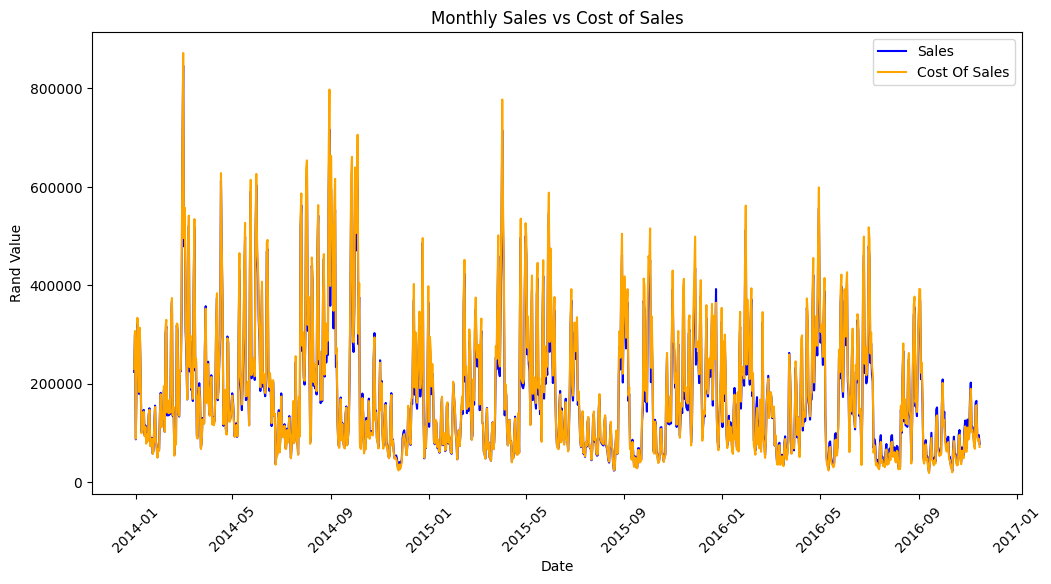

In [0]:
#Visualizations
# Line chart Sales comparing with the  Cost of Sales
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to pandas for plotting
df_pandas = df.toPandas()

plt.figure(figsize=(12,6))
sns.lineplot(data=df_pandas, x="Date", y="Sales", label="Sales", color="blue")
sns.lineplot(data=df_pandas, x="Date", y="Cost Of Sales", label="Cost Of Sales", color="orange")
plt.title("Monthly Sales vs Cost of Sales")
plt.xlabel("Date")
plt.ylabel("Rand Value")
plt.legend()
plt.xticks(rotation=45)  # Rotate dates for readability
plt.show()

# Reports 

In [0]:
# showing  Which years were profitable and which were loss‑making

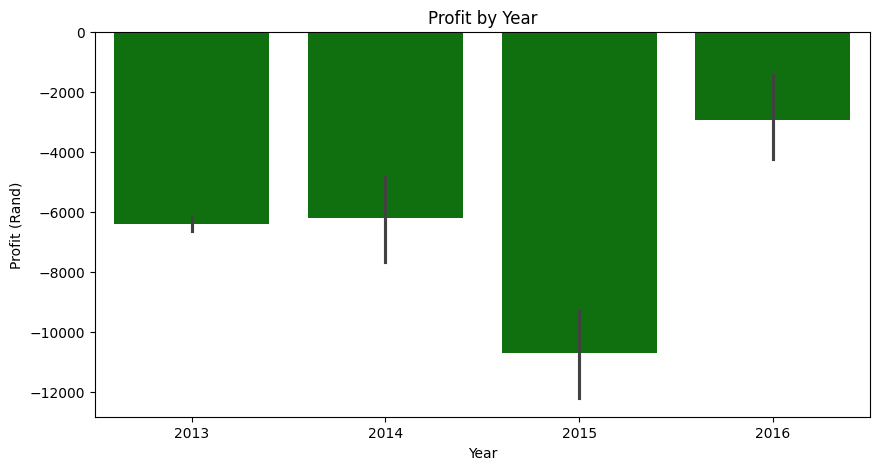

In [0]:
# Bar chart Profit by Year
import matplotlib.pyplot as plt
import seaborn as sns
df_pandas["Year"] = df_pandas["Date"].dt.year
df_pandas["Profit"] = df_pandas["Sales"] - df_pandas["Cost Of Sales"]
plt.figure(figsize=(10,5))
sns.barplot(data=df_pandas, x="Year", y="Profit", color="green")
plt.title("Profit by Year")
plt.xlabel("Year")
plt.ylabel("Profit (Rand)")
plt.show()

In [0]:
#  Summary Metrics 
total_sales = df_pandas["Sales"].sum()
total_cost = df_pandas["Cost Of Sales"].sum()
total_profit = total_sales - total_cost
profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: R{total_sales:,.2f}")
print(f"Total Cost of Sales: R{total_cost:,.2f}")
print(f"Total Profit: R{total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")


Total Sales: R186,909,828.26
Total Cost of Sales: R194,026,109.45
Total Profit: R-7,116,281.19
Profit Margin: -3.81%


In [0]:
# analyze profitability trends over time,To see how profit changes month by month
# identify which months are more profitable and which months are weaker 

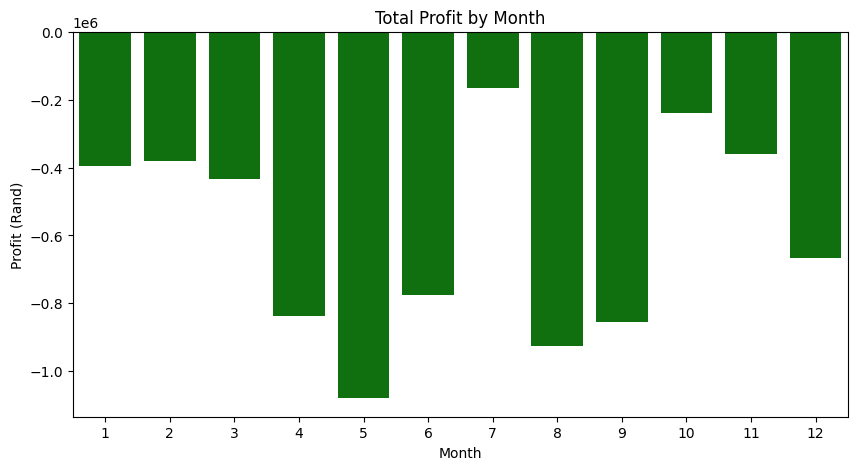

In [0]:
#profit by Month (bar chart)
df_pandas["Month"] = df_pandas["Date"].dt.month
df_pandas["Profit"] = df_pandas["Sales"] - df_pandas["Cost Of Sales"]
monthly_profit = df_pandas.groupby("Month")["Profit"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x="Month", y="Profit", data=monthly_profit, color="green")
plt.title("Total Profit by Month")
plt.ylabel("Profit (Rand)")
plt.show()

#  calculating the running total of sales over time

In [0]:
#To Shows whether sales are steadily increasing, plateauing, or declining

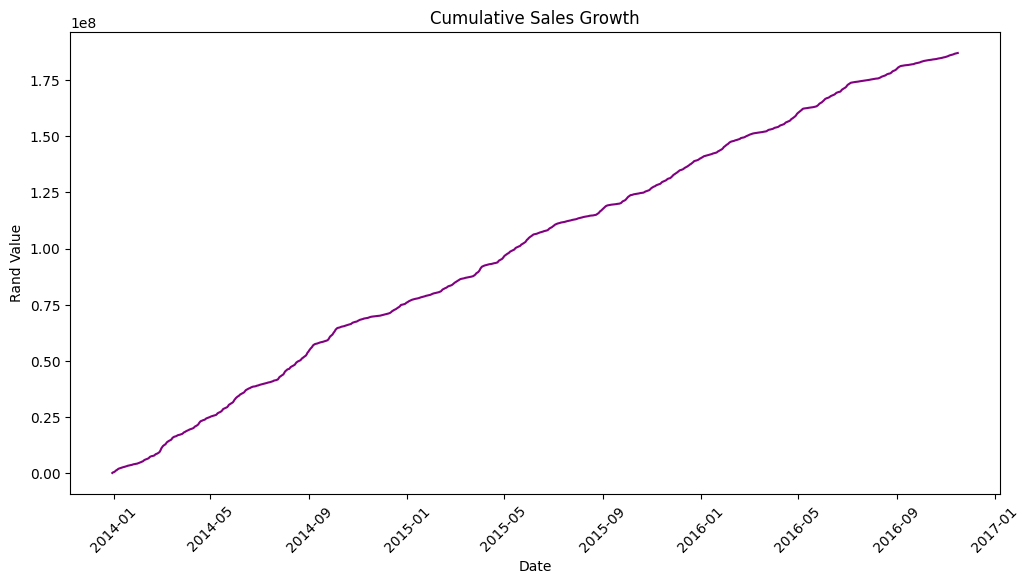

In [0]:
 #Cumulative Sales (line chart)
df_pandas["Cumulative_Sales"] = df_pandas["Sales"].cumsum()

plt.figure(figsize=(12,6))
sns.lineplot(x="Date", y="Cumulative_Sales", data=df_pandas, color="purple")
plt.title("Cumulative Sales Growth")
plt.xticks(rotation=45)
plt.ylabel("Rand Value")
plt.show()

# analyze daily business performance from two perspectives

In [0]:
 #Revenue (Sales)checking How much money is coming in each day.
 #Volume (Quantity Sold)checking How many units are being sold each day


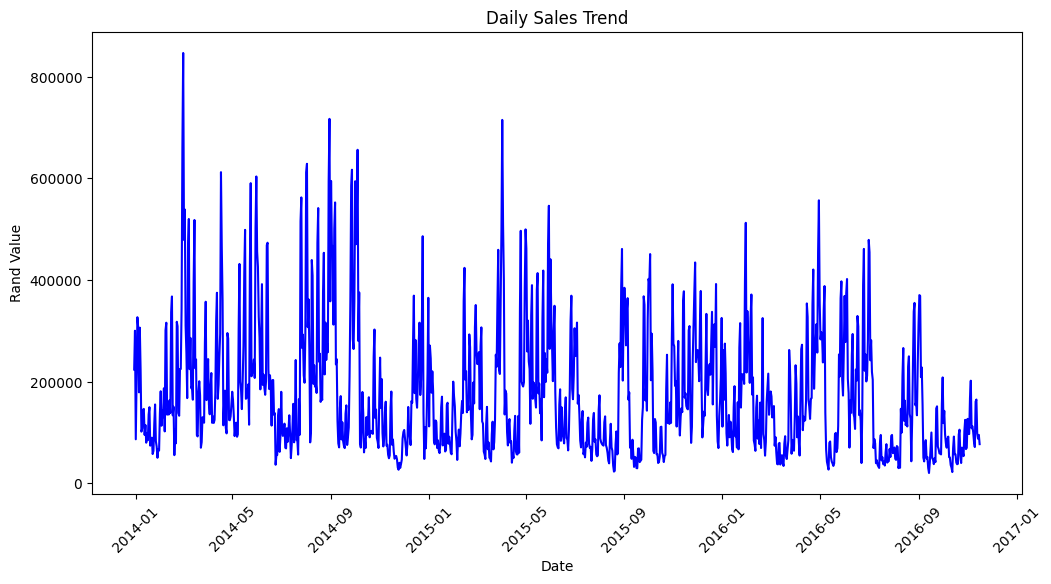

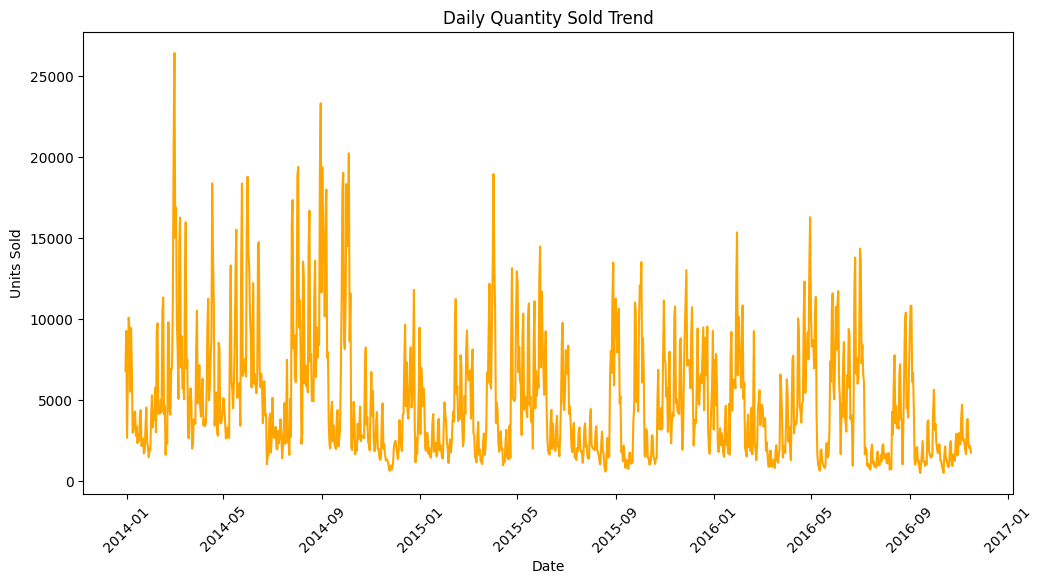

In [0]:
# 1. Daily Sales Trend
plt.figure(figsize=(12,6))
sns.lineplot(x="Date", y="Sales", data=df_pandas, color="blue")
plt.title("Daily Sales Trend")
plt.xticks(rotation=45)
plt.ylabel("Rand Value")
plt.show()

# 2. Quantity Sold Trend
plt.figure(figsize=(12,6))
sns.lineplot(x="Date", y="Quantity Sold", data=df_pandas, color="orange")
plt.title("Daily Quantity Sold Trend")
plt.xticks(rotation=45)
plt.ylabel("Units Sold")
plt.show()

# calculates the average of all daily sales values.


In [0]:
# Average dail sales,to compare actual daily sales against the overall average.it helps to check whether sales on specific days are above or below the average.
# monthly quantity sold,checking measure total product demand per month.


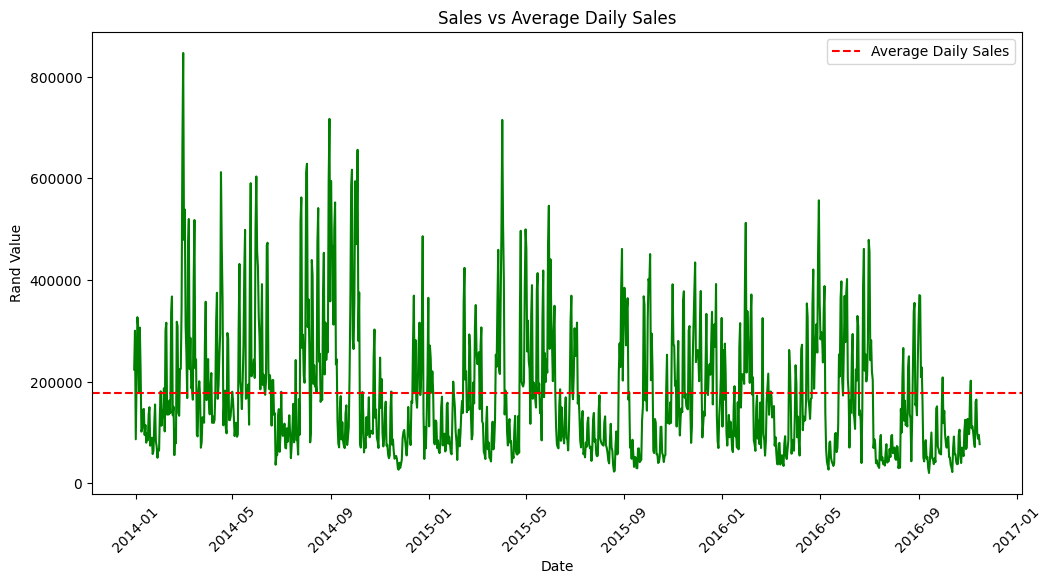

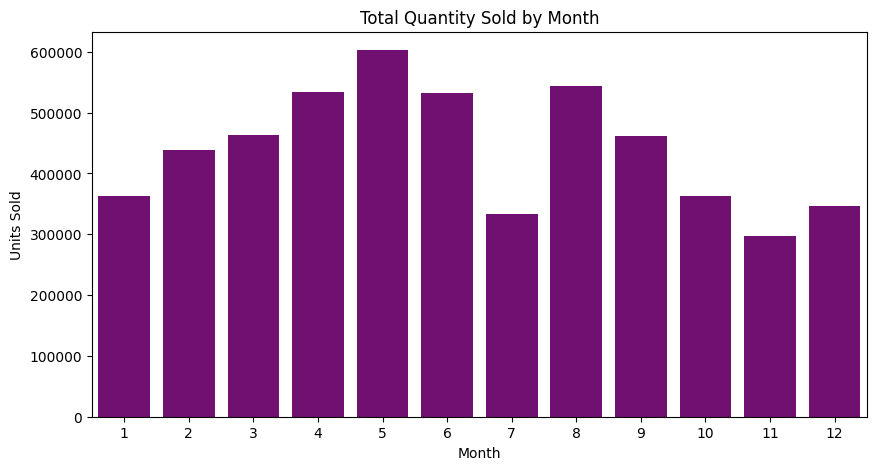

In [0]:
# Average Daily Sales (horizontal line for reference)
avg_daily_sales = df_pandas["Sales"].mean()
plt.figure(figsize=(12,6))
sns.lineplot(x="Date", y="Sales", data=df_pandas, color="green")
plt.axhline(avg_daily_sales, color="red", linestyle="--", label="Average Daily Sales")
plt.title("Sales vs Average Daily Sales")
plt.xticks(rotation=45)
plt.ylabel("Rand Value")
plt.legend()
plt.show()

# Monthly Quantity Sold (bar chart)
df_pandas["Month"] = df_pandas["Date"].dt.month
monthly_quantity = df_pandas.groupby("Month")["Quantity Sold"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(x="Month", y="Quantity Sold", data=monthly_quantity, color="purple")
plt.title("Total Quantity Sold by Month")
plt.ylabel("Units Sold")
plt.show()

#  checking the relationship between sales volume and profitability per unit

In [0]:
#checking weather higher sales days correspond to higher profit per unit.Or do discounts, promotions, or costs reduce profit per unit when sales spike
#the purpose of the graph is to Help to see if selling more units actually increases profit per unit, or if margins shrink.

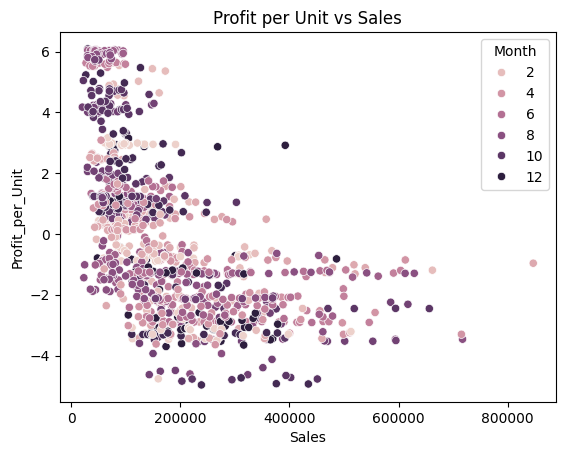

In [0]:
#calculates the profit earned per unit sold
df_pandas["Profit_per_Unit"] = (df_pandas["Sales"] - df_pandas["Cost Of Sales"]) / df_pandas["Quantity Sold"]
df_pandas["Month"] = df_pandas["Date"].dt.month

sns.scatterplot(x="Sales", y="Profit_per_Unit", data=df_pandas, hue="Month")
plt.title("Profit per Unit vs Sales")
plt.show()

In [0]:
# checking the distribution and variability of gross profit percentage across different months.
#the purpose is See if gross profit % is consistent month-to-month or if it fluctuates.
#Identify months where profit margins are higher or lower

# checking the average sales performance across different days of the week.

In [0]:
#See which days consistently generate higher or lower sales

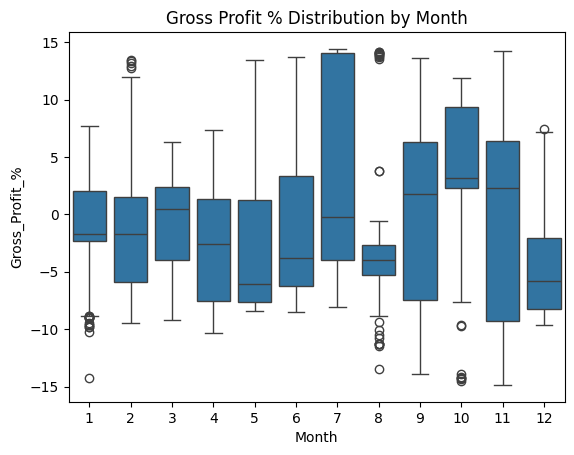

In [0]:
# Calculate Gross Profit % before plotting
df_pandas["Gross_Profit_%"] = (df_pandas["Profit"] / df_pandas["Sales"]) * 100

sns.boxplot(x="Month", y="Gross_Profit_%", data=df_pandas)
plt.title("Gross Profit % Distribution by Month")
plt.show()


# analyzing sales performance across different days of the week

In [0]:
#Which day of the week has the highest average sales and Are weekends stronger than weekdays.

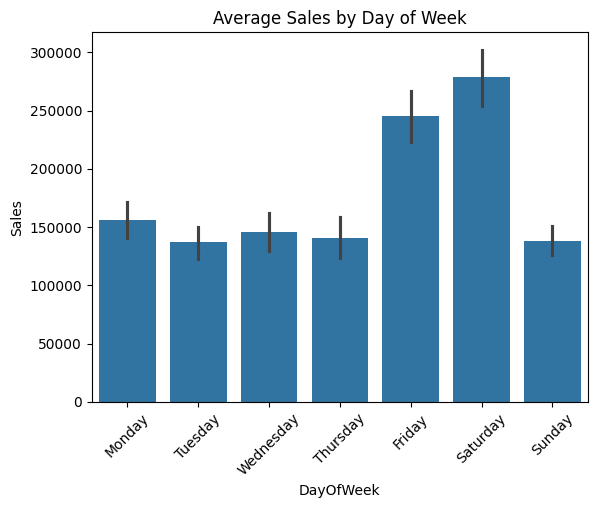

In [0]:
sns.barplot(x="DayOfWeek", y="Sales", data=df_pandas)
plt.title("Average Sales by Day of Week")
plt.xticks(rotation=45)
plt.show()


#  analyzing the distribution of elasticity values from dataset

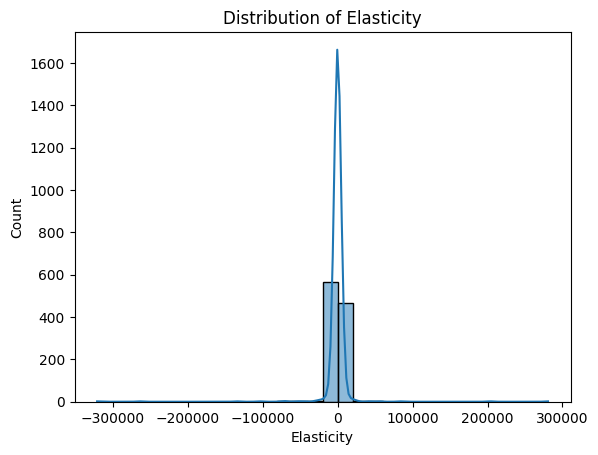

In [0]:
# Calculate price elasticity (% change in quantity / % change in price)
import numpy as np

# Convert to float to handle decimal types
df_pandas["Elasticity"] = (df_pandas["Quantity Sold"].pct_change() / 
                            df_pandas["Price_per_Unit"].astype(float).pct_change())

# Remove infinite and NaN values for plotting
elasticity_clean = df_pandas["Elasticity"].replace([np.inf, -np.inf], np.nan).dropna()

sns.histplot(elasticity_clean, bins=30, kde=True)
plt.title("Distribution of Elasticity")
plt.show()
